# THz Circuits: Where Lumped Elements Stop Working

At THz frequencies (100 GHz-10 THz), a wavelength in a typical dielectric
is only hundreds of microns to a few millimeters -- so ordinary
circuit-board trace lengths, often already millimeter-scale even at GHz,
routinely violate the standard lambda/10 lumped-element rule of thumb and
have to be treated as DISTRIBUTED transmission lines instead.

This notebook builds a microstrip transmission line's 2-port ABCD matrix
-- and reuses `dgs.paraxial_optics_abcd.compose_system` and
`is_unimodular` UNMODIFIED to verify it, the same functions already used
for ray optics. Ray optics and RF network theory are the same $2\times2$
linear algebra, made literal here rather than asserted. A closing
identity: slicing the line into $N$ discrete physical segments and
cascading their matrices reproduces the continuous line's answer EXACTLY,
for every $N$ tested, not just as $N$ grows large. Engine:
`dgs/thz_circuits.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import thz_circuits as tc
from dgs.paraxial_optics_abcd import compose_system, is_unimodular

sp.init_printing()
print('Setup complete.')


Setup complete.


## 1. The Lambda/10 Rule: Symbolic and Numeric

Electrical length $\theta=2\pi L/\lambda$; the lumped-element
approximation needs $L\ll\lambda/10$.


In [2]:
sym = tc.lumped_element_validity_symbolic()
display(Math(r'\theta = ' + sp.latex(sym['electrical_length_theta'])))
display(Math(r'\text{lumped valid: } ' + sp.latex(sym['lumped_condition'])))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
print('A 2mm trace at increasing frequency:')
for f in (1e9, 100e9, 300e9, 1e12, 3e12):
    check = tc.is_lumped_valid(trace_length_m=2e-3, frequency_hz=f)
    print(f"  f={f:>8.2e} Hz: lambda={check['wavelength_m']*1e3:>9.4f} mm, "
          f"L/lambda={check['trace_length_over_wavelength']:>7.4f}, lumped valid: {check['lumped_valid']}")


A 2mm trace at increasing frequency:
  f=1.00e+09 Hz: lambda= 299.7925 mm, L/lambda= 0.0067, lumped valid: True
  f=1.00e+11 Hz: lambda=   2.9979 mm, L/lambda= 0.6671, lumped valid: False
  f=3.00e+11 Hz: lambda=   0.9993 mm, L/lambda= 2.0014, lumped valid: False
  f=1.00e+12 Hz: lambda=   0.2998 mm, L/lambda= 6.6713, lumped valid: False
  f=3.00e+12 Hz: lambda=   0.0999 mm, L/lambda=20.0138, lumped valid: False


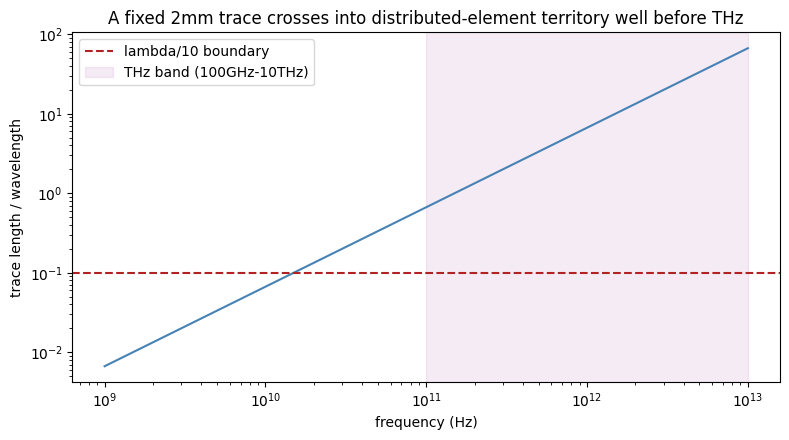

In [4]:
freqs = np.logspace(9, 13, 200)
ratios = [tc.is_lumped_valid(2e-3, f)['trace_length_over_wavelength'] for f in freqs]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(freqs, ratios, color='steelblue')
ax.axhline(0.1, color='firebrick', ls='--', label='lambda/10 boundary')
ax.axvspan(1e11, 1e13, alpha=0.08, color='purple', label='THz band (100GHz-10THz)')
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('trace length / wavelength')
ax.set_title('A fixed 2mm trace crosses into distributed-element territory well before THz')
ax.legend()
plt.tight_layout()
plt.savefig('thz_circuits_lambda10_boundary.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Microstrip Transmission Line

Quasi-TEM (Hammerstad-Jensen) approximation: effective permittivity and
characteristic impedance from trace width $w$, substrate height $h$, and
substrate $\varepsilon_r$.


In [5]:
w, h, eps_r = 150e-6, 100e-6, 3.5   # 150um trace, 100um substrate
eps_eff = tc.microstrip_effective_permittivity(w, h, eps_r)
Z0 = tc.microstrip_characteristic_impedance(w, h, eps_r)
print(f'w={w*1e6:.0f}um, h={h*1e6:.0f}um, eps_r={eps_r}')
print(f'eps_eff = {eps_eff:.4f}  (between 1=air and eps_r={eps_r})')
print(f'Z0 = {Z0:.2f} ohm')

f_design = 100e9
beta = tc.microstrip_propagation_constant(f_design, w, h, eps_r)
print(f'beta @ {f_design/1e9:.0f} GHz = {beta:.2f} rad/m')


w=150um, h=100um, eps_r=3.5
eps_eff = 2.6667  (between 1=air and eps_r=3.5)
Z0 = 63.89 ohm
beta @ 100 GHz = 3422.50 rad/m


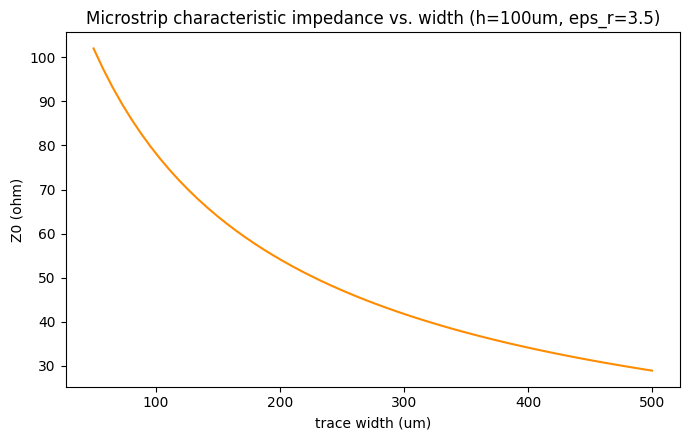

In [6]:
widths = np.linspace(50e-6, 500e-6, 60)
Z0s = [tc.microstrip_characteristic_impedance(wi, h, eps_r) for wi in widths]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(widths*1e6, Z0s, color='darkorange')
ax.set_xlabel('trace width (um)'); ax.set_ylabel('Z0 (ohm)')
ax.set_title(f'Microstrip characteristic impedance vs. width (h={h*1e6:.0f}um, eps_r={eps_r})')
plt.tight_layout()
plt.savefig('thz_circuits_Z0_vs_width.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. The ABCD Matrix: Shared Code, Not a Shared Metaphor

`transmission_line_ABCD` builds a COMPLEX $2\times2$ matrix (unlike ray
optics' real-valued matrices), then hands it straight to
`dgs.paraxial_optics_abcd.compose_system` and `is_unimodular` -- neither
function has any idea this matrix came from RF network theory instead of
a telescope.


In [7]:
L_line = 0.002   # 2mm line
M = tc.transmission_line_ABCD(beta, Z0, L_line)
print('ABCD matrix:')
print(M)
print(f"\nis_unimodular (det=1, from ray-optics code, unmodified): {is_unimodular(M, tol=1e-6)}")


ABCD matrix:
[[0.84628915+0.00000000e+00j 0.        +3.40373817e+01j]
 [0.        +8.33773522e-03j 0.84628915+0.00000000e+00j]]

is_unimodular (det=1, from ray-optics code, unmodified): True


## 4. The Discrete-Geometry Identity

Slicing the line into $N$ physical segments and cascading their matrices
via `compose_system` reproduces the single continuous line's ABCD matrix
EXACTLY -- checked here for $N=1,2,5,10,50$, not just shown to converge.


In [8]:
check = tc.verify_discrete_geometry_identity(beta, Z0, total_length_m=L_line)
for N, r in check['per_N_results'].items():
    print(f"N={N:>3}: max diff from full-length ABCD = {r['max_abs_diff_from_full_length']:.3e}, "
          f"unimodular: {r['unimodular']}")
print(f"\nall N match exactly: {check['all_match']}")


N=  1: max diff from full-length ABCD = 0.000e+00, unimodular: True
N=  2: max diff from full-length ABCD = 7.105e-15, unimodular: True
N=  5: max diff from full-length ABCD = 1.735e-18, unimodular: True
N= 10: max diff from full-length ABCD = 2.842e-14, unimodular: True
N= 50: max diff from full-length ABCD = 5.684e-14, unimodular: True

all N match exactly: True


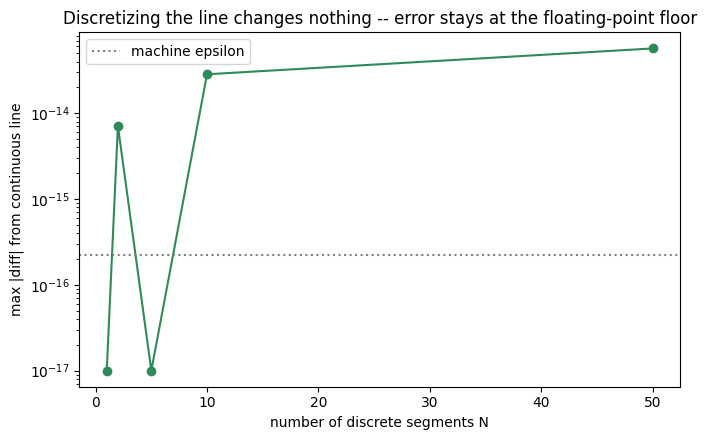

In [9]:
Ns = list(check['per_N_results'].keys())
diffs = [check['per_N_results'][N]['max_abs_diff_from_full_length'] for N in Ns]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(Ns, [max(d, 1e-17) for d in diffs], 'o-', color='seagreen')
ax.axhline(np.finfo(float).eps, color='gray', ls=':', label='machine epsilon')
ax.set_xlabel('number of discrete segments N'); ax.set_ylabel('max |diff| from continuous line')
ax.set_title('Discretizing the line changes nothing -- error stays at the floating-point floor')
ax.legend()
plt.tight_layout()
plt.savefig('thz_circuits_discrete_geometry.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. 3D Geometry

The physical microstrip cross-section a THz circuit designer actually
lays out -- conducting trace on top of a dielectric substrate -- built
with torch tensors.


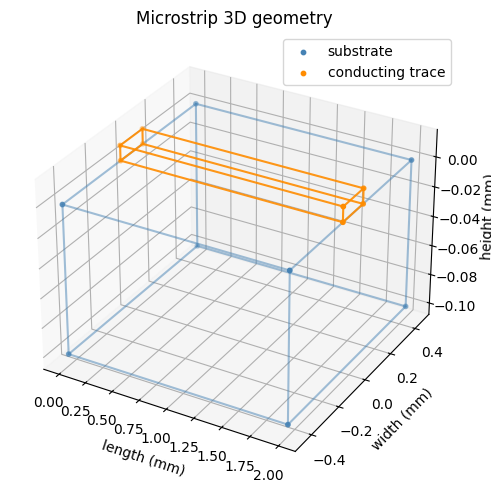

In [10]:
try:
    import torch
    geom = tc.microstrip_geometry_3d(w=w*1e3, h=h*1e3, length=L_line*1e3, trace_thickness=0.01)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(projection='3d')

    def plot_box(verts, color, alpha, label):
        v = verts.numpy()
        edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
        for a, b in edges:
            ax.plot(*zip(v[a], v[b]), color=color, alpha=alpha)
        ax.scatter(*v.T, color=color, s=10, label=label)

    plot_box(geom['substrate_vertices'], 'steelblue', 0.5, 'substrate')
    plot_box(geom['trace_vertices'], 'darkorange', 0.9, 'conducting trace')
    ax.set_xlabel('length (mm)'); ax.set_ylabel('width (mm)'); ax.set_zlabel('height (mm)')
    ax.set_title('Microstrip 3D geometry')
    ax.legend()
    plt.tight_layout()
    plt.savefig('thz_circuits_3d_geometry.png', dpi=100, bbox_inches='tight')
    plt.show()
except ImportError:
    print('torch not available in this kernel -- run under py 3.12 for this section')


## 6. Engineering Interpretation

- Section 1's boundary crossing at well below 100 GHz (Section 1's plot)
  is the actual design consequence: a THz circuit can't inherit
  GHz-band "just use lumped RLC" intuition even loosely -- the crossover
  happens for ordinary trace lengths before THz frequencies are even
  reached.
- Section 3 reusing `compose_system`/`is_unimodular` UNCHANGED across two
  physically unrelated domains (ray optics, RF networks) is the actual
  point, not a coincidence to note in passing: both are 2-port linear
  systems with a conserved determinant, and the code correctly doesn't
  care which domain it's being asked about.
- Section 4's exact (not asymptotic) discretization identity matters
  practically: a designer laying out a transmission line as several
  physical segments (e.g. around a bend, or split across two board
  layers) doesn't introduce ANY electrical error from the segmentation
  itself, as long as each segment's own ABCD model is exact.


## 7. Research Discussion

- `dgs.thz_waveguide_dispersion_relation` covers WAVE PROPAGATION physics
  (the effective-mass dispersion relation) for a THz waveguide; this
  module covers CIRCUIT-level 2-port network analysis for a THz
  transmission line -- genuinely complementary, not overlapping, and a
  natural next step is connecting the two: does the waveguide's GVD
  (group velocity dispersion) show up as frequency-dependent behavior in
  a `transmission_line_ABCD` built from `microstrip_propagation_constant`
  evaluated across a bandwidth, rather than at one design frequency?
- The Hammerstad-Jensen formula here only covers $w/h\ge1$; a THz design
  with a narrow trace relative to substrate height needs the OTHER branch
  of that formula (different closed form), not currently implemented.
- `dgs.paraxial_optics_abcd`'s Gaussian-beam $q$-parameter (Kogelnik's
  law, the SAME ABCD-matrix Mobius transformation used for ray optics)
  has a direct RF-network analog too: the same Mobius transform relates
  input/output reflection coefficients through a 2-port network in
  microwave engineering -- a third domain the same math already covers.


## 8. Possible Experiments

1. Extend `verify_discrete_geometry_identity` to a LOSSY transmission
   line (complex propagation constant, alpha+i*beta) and confirm the
   exact discretization identity still holds -- loss shouldn't break the
   additive-phase argument, but it's worth checking rather than assuming.
2. Build a simple THz matching network (e.g. a single quarter-wave
   transformer) as a cascade of `transmission_line_ABCD` calls via
   `compose_system`, and verify its input impedance matches the classic
   closed-form quarter-wave transformer result.
3. Sweep substrate `eps_r` across real THz-relevant materials (quartz,
   silicon, sapphire) and compare the resulting lambda/10 crossover
   frequency for a fixed trace length -- which substrate buys the most
   "GHz-band intuition still applies" headroom?


## 9. Future Improvements

- `microstrip_characteristic_impedance` doesn't account for conductor
  loss or dielectric loss tangent, both significant at THz frequencies --
  a lossy extension would need a complex propagation constant, not just a
  complex ABCD matrix built from a real beta.
- `microstrip_geometry_3d` draws a simple rectangular box geometry; a
  more realistic THz trace cross-section (trapezoidal, from real
  fabrication undercut) would need a less trivial vertex set.
